# EDA and Preprocessing - FC110554 Chandira

This notebook performs data loading, cleaning, feature engineering, and encoding for the Video Games dataset, and saves a cleaned dataset for modeling.


In [1]:
# Step 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


In [2]:
# Step 2: Load Data
data_path = "../../src/data/Video_Games_Sales_as_at_22_Dec_2016.csv"
df = pd.read_csv(data_path)
df.head()


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Step 3: Inspect data
print(df.info())
df.describe(include='all').transpose().head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,16717,11562,Need for Speed: Most Wanted,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Platform,16719,31,PS2,2161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year_of_Release,16450.0,NaN,NaN,NaN,2006.487356,5.878995,1980.0,2003.0,2007.0,2010.0,2020.0
Genre,16717,12,Action,3370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Publisher,16665,581,Electronic Arts,1356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NA_Sales,16719.0,NaN,NaN,NaN,0.26333,0.813514,0.0,0.0,0.08,0.24,41.36
EU_Sales,16719.0,NaN,NaN,NaN,0.145025,0.503283,0.0,0.0,0.02,0.11,28.96
JP_Sales,16719.0,NaN,NaN,NaN,0.077602,0.308818,0.0,0.0,0.0,0.04,10.22
Other_Sales,16719.0,NaN,NaN,NaN,0.047332,0.18671,0.0,0.0,0.01,0.03,10.57
Global_Sales,16719.0,NaN,NaN,NaN,0.533543,1.547935,0.01,0.06,0.17,0.47,82.53


In [4]:
# Step 4: Handle missing values and types
# Drop rows with missing target
if 'Global_Sales' in df.columns:
    df = df.dropna(subset=['Global_Sales'])

# Ensure Year_of_Release is integer
if 'Year_of_Release' in df.columns:
    df = df.dropna(subset=['Year_of_Release'])
    df['Year_of_Release'] = df['Year_of_Release'].astype(int)

# Clean User_Score (convert 'tbd' to NaN then numeric)
if 'User_Score' in df.columns:
    df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')

# Fill selected numeric columns with median
def fill_median(col_name):
    if col_name in df.columns:
        df[col_name] = df[col_name].fillna(df[col_name].median())

for col in ['Critic_Score', 'Critic_Count', 'User_Score', 'User_Count']:
    fill_median(col)

# Drop very high-cardinality or sparsely populated columns as needed
for col in ['Developer']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Drop rows where 'Rating' is missing if present
if 'Rating' in df.columns:
    df = df.dropna(subset=['Rating'])

print('After cleaning:', df.shape)


After cleaning: (9769, 15)


In [6]:
# Step 5: Feature engineering
# Game age
if 'Year_of_Release' in df.columns:
    df['Game_Age'] = 2025 - df['Year_of_Release']

# Drop text columns not used for modeling (keep Name separately if needed)
for col in ['Name']:
    if col in df.columns:
        pass  # Keep Name for optional analysis; drop later during modeling

print('Columns after feature engineering:', df.columns.tolist())


Columns after feature engineering: ['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Rating', 'Game_Age']


In [7]:
# Step 6: Encode categorical variables
categorical_cols = []
for col in ['Platform', 'Genre', 'Publisher', 'Rating']:
    if col in df.columns:
        categorical_cols.append(col)

# Group rare publishers if present
if 'Publisher' in categorical_cols:
    publisher_counts = df['Publisher'].value_counts()
    rare_publishers = publisher_counts[publisher_counts < 50].index
    df['Publisher'] = df['Publisher'].apply(lambda x: 'Other' if x in rare_publishers else x)

# One-hot encode
if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print('After encoding:', df.shape)


After encoding: (9769, 77)


In [8]:
# Step 7: Final cleanup
# Drop rows with any remaining missing numeric values
numeric_cols = df.select_dtypes(include=[np.number]).columns
df = df.dropna(subset=numeric_cols)

print('Final shape:', df.shape)
print(df.columns)



Final shape: (9769, 77)
Index(['Name', 'Year_of_Release', 'NA_Sales', 'EU_Sales', 'JP_Sales',
       'Other_Sales', 'Global_Sales', 'Critic_Score', 'Critic_Count',
       'User_Score', 'User_Count', 'Game_Age', 'Platform_DC', 'Platform_DS',
       'Platform_GBA', 'Platform_GC', 'Platform_PC', 'Platform_PS',
       'Platform_PS2', 'Platform_PS3', 'Platform_PS4', 'Platform_PSP',
       'Platform_PSV', 'Platform_Wii', 'Platform_WiiU', 'Platform_X360',
       'Platform_XB', 'Platform_XOne', 'Genre_Adventure', 'Genre_Fighting',
       'Genre_Misc', 'Genre_Platform', 'Genre_Puzzle', 'Genre_Racing',
       'Genre_Role-Playing', 'Genre_Shooter', 'Genre_Simulation',
       'Genre_Sports', 'Genre_Strategy', 'Publisher_Acclaim Entertainment',
       'Publisher_Activision', 'Publisher_Atari',
       'Publisher_Bethesda Softworks', 'Publisher_Capcom',
       'Publisher_Codemasters', 'Publisher_D3Publisher',
       'Publisher_Deep Silver', 'Publisher_Disney Interactive Studios',
       'Publisher_Ei

In [9]:
# Step 8: Save cleaned data
output_path = "../../src/data/processed/fc110554_cleaned_vgsales.csv"
df.to_csv(output_path, index=False)
print(f"Cleaned data saved to: {output_path}")


Cleaned data saved to: ../../src/data/processed/fc110554_cleaned_vgsales.csv


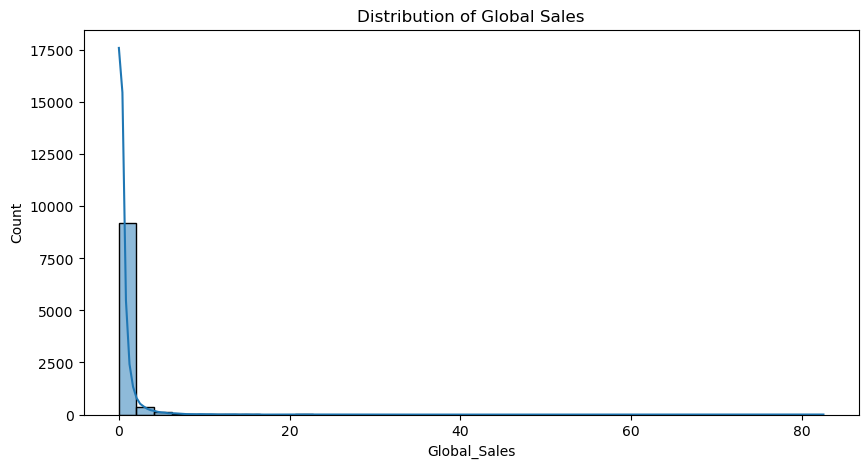

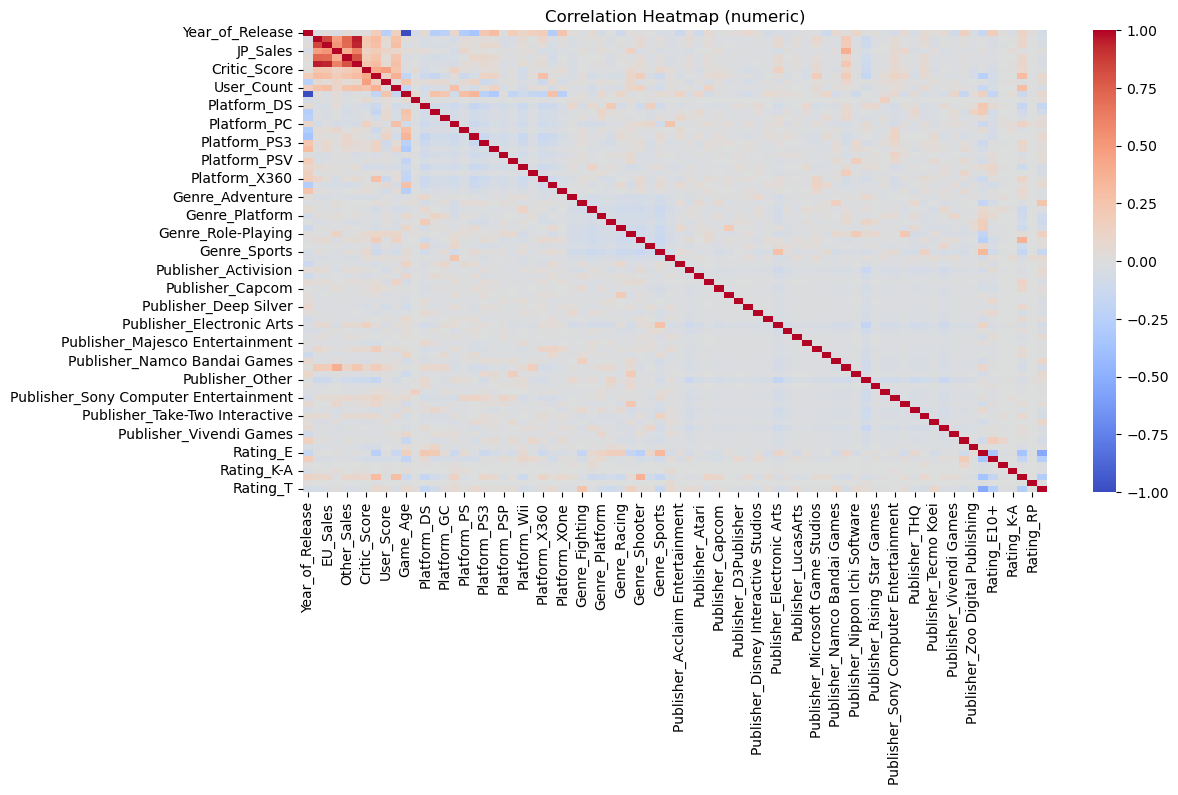

In [10]:
# Optional: Quick EDA visuals
plt.figure(figsize=(10,5))
sns.histplot(df['Global_Sales'], bins=40, kde=True)
plt.title('Distribution of Global Sales')
plt.show()

plt.figure(figsize=(12,6))
num_corr = df.corr(numeric_only=True)
sns.heatmap(num_corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (numeric)')
plt.show()
